In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, torch

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if f.endswith('.pt'):
            print(os.path.join(root, f))

/content/drive/MyDrive/YOLO_PlantDoc/train/weights/last.pt
/content/drive/MyDrive/YOLO_PlantDoc/train/weights/best.pt
/content/drive/MyDrive/YOLO_PlantDoc/train_part2/weights/last.pt


In [6]:
import torch

# Check feature bank
bank_data = torch.load('/content/drive/MyDrive/PlantDoc_Project_2026/Clip_Dcon_features_bank.pt',
                        map_location='cpu')
print("=== BANK CLASS NAMES ===")
for i, name in enumerate(bank_data['class_names']):
    print(f"  {i}: {name}")
print(f"\nEmbeddings shape: {bank_data['embeddings'].shape}")
print(f"Labels shape: {bank_data['labels'].shape}")

=== BANK CLASS NAMES ===
  0: Apple Scab Leaf
  1: Apple leaf
  2: Apple rust leaf
  3: Bell_pepper leaf spot
  4: Bell_pepper leaf
  5: Blueberry leaf
  6: Cherry leaf
  7: Corn Gray leaf spot
  8: Corn leaf blight
  9: Corn rust leaf
  10: Peach leaf
  11: Potato leaf early blight
  12: Potato leaf late blight
  13: Potato leaf
  14: Raspberry leaf
  15: Soyabean leaf
  16: Soybean leaf
  17: Squash Powdery mildew leaf
  18: Strawberry leaf
  19: Tomato Early blight leaf
  20: Tomato Septoria leaf spot
  21: Tomato leaf bacterial spot
  22: Tomato leaf late blight
  23: Tomato leaf mosaic virus
  24: Tomato leaf yellow virus
  25: Tomato leaf
  26: Tomato mold leaf
  27: Tomato two spotted spider mites leaf
  28: grape leaf black rot
  29: grape leaf

Embeddings shape: torch.Size([11897, 512])
Labels shape: torch.Size([11897])


In [7]:
# Check DINOv2 checkpoint
ckpt = torch.load('/content/drive/MyDrive/PlantDoc_Project_2026/dinov2_species_best.pt',
                   map_location='cpu')
print("=== DINOV2 SPECIES ===")
for species, idx in sorted(ckpt['species_to_idx'].items(), key=lambda x: x[1]):
    print(f"  {idx}: {species}")

=== DINOV2 SPECIES ===
  0: Apple
  1: Bell Pepper
  2: Blueberry
  3: Cherry
  4: Corn
  5: Grape
  6: Peach
  7: Potato
  8: Raspberry
  9: Soybean
  10: Squash
  11: Strawberry
  12: Tomato


In [8]:
!pip install ultralytics transformers -q

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.8 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import os, torch, cv2
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from collections import defaultdict
from torchvision import transforms
from transformers import AutoModel, CLIPModel, CLIPProcessor
from ultralytics import YOLO

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cuda


In [10]:
class DINOv2SpeciesClassifier(nn.Module):
    def __init__(self, num_species):
        super().__init__()
        self.backbone = AutoModel.from_pretrained("facebook/dinov2-base")
        for p in self.backbone.parameters():
            p.requires_grad = False
        hidden_dim = self.backbone.config.hidden_size  # 768
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim), nn.Linear(hidden_dim, 256),
            nn.GELU(), nn.Dropout(0.3), nn.Linear(256, num_species)
        )

    def forward(self, x):
        return self.classifier(
            self.backbone(pixel_values=x).last_hidden_state[:, 0, :]
        )

class DConAdapter(nn.Module):
    def __init__(self, input_dim=512, bottleneck_dim=128):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, bottleneck_dim)
        self.dilated_conv = nn.Conv1d(1, 1, kernel_size=3, padding=2, dilation=2)
        self.fc2 = nn.Linear(bottleneck_dim, input_dim)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        identity = x
        x = F.relu(self.fc1(x))
        x = F.relu(self.dilated_conv(x.unsqueeze(1))).squeeze(1)
        return self.fc2(self.dropout(x)) + identity

print("Model classes defined.")

Model classes defined.


In [11]:
YOLO_PATH = '/content/drive/MyDrive/PlantDoc_Project_2026/Plantdoc_Yolo_v1_best.pt'
DINO_PATH = '/content/drive/MyDrive/PlantDoc_Project_2026/dinov2_species_best.pt'
BANK_PATH = '/content/drive/MyDrive/PlantDoc_Project_2026/Clip_Dcon_features_bank.pt'

# 1. YOLO
yolo_model = YOLO(YOLO_PATH)
print("YOLO loaded.")

# 2. CLIP + DCon
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_proc  = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()
dcon_adapter = DConAdapter(input_dim=512).to(device)
dcon_adapter.eval()
print("CLIP + DCon loaded.")

# 3. DINOv2
dino_ckpt      = torch.load(DINO_PATH, map_location=device)
species_to_idx = dino_ckpt['species_to_idx']
idx_to_species = dino_ckpt['idx_to_species']
dino_model     = DINOv2SpeciesClassifier(num_species=len(species_to_idx)).to(device)
dino_model.load_state_dict(dino_ckpt['model_state'])
dino_model.eval()
print(f"DINOv2 loaded. Species: {list(idx_to_species.values())}")

# 4. Feature bank
bank_data  = torch.load(BANK_PATH, map_location=device)
bank_embs  = F.normalize(bank_data['embeddings'].float().to(device), dim=-1)
bank_labels = bank_data['labels'].to(device)
class_names = bank_data['class_names']
print(f"Bank loaded. Shape: {bank_embs.shape}")

YOLO loaded.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

CLIP + DCon loaded.


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 loaded. Species: ['Apple', 'Bell Pepper', 'Blueberry', 'Cherry', 'Corn', 'Grape', 'Peach', 'Potato', 'Raspberry', 'Soybean', 'Squash', 'Strawberry', 'Tomato']
Bank loaded. Shape: torch.Size([11897, 512])


In [12]:
# Maps each bank disease name → species your DINOv2 predicts
BANK_CLASS_TO_SPECIES = {
    "Apple Scab Leaf":                       "Apple",
    "Apple leaf":                            "Apple",
    "Apple rust leaf":                       "Apple",
    "Bell_pepper leaf spot":                 "Bell Pepper",
    "Bell_pepper leaf":                      "Bell Pepper",
    "Blueberry leaf":                        "Blueberry",
    "Cherry leaf":                           "Cherry",
    "Corn Gray leaf spot":                   "Corn",
    "Corn leaf blight":                      "Corn",
    "Corn rust leaf":                        "Corn",
    "Peach leaf":                            "Peach",
    "Potato leaf early blight":              "Potato",
    "Potato leaf late blight":               "Potato",
    "Potato leaf":                           "Potato",
    "Raspberry leaf":                        "Raspberry",
    "Soyabean leaf":                         "Soybean",
    "Soybean leaf":                          "Soybean",
    "Squash Powdery mildew leaf":            "Squash",
    "Strawberry leaf":                       "Strawberry",
    "Tomato Early blight leaf":              "Tomato",
    "Tomato Septoria leaf spot":             "Tomato",
    "Tomato leaf bacterial spot":            "Tomato",
    "Tomato leaf late blight":               "Tomato",
    "Tomato leaf mosaic virus":              "Tomato",
    "Tomato leaf yellow virus":              "Tomato",
    "Tomato leaf":                           "Tomato",
    "Tomato mold leaf":                      "Tomato",
    "Tomato two spotted spider mites leaf":  "Tomato",
    "grape leaf black rot":                  "Grape",
    "grape leaf":                            "Grape",
}

# Reverse: species → set of disease names in bank
SPECIES_TO_DISEASES = defaultdict(set)
for disease, species in BANK_CLASS_TO_SPECIES.items():
    SPECIES_TO_DISEASES[species].add(disease)

# Verify all 30 bank classes are mapped
missing = [cn for cn in class_names if cn not in BANK_CLASS_TO_SPECIES]
print(f"Missing mappings: {missing if missing else 'None — all 30 mapped correctly!'}")
print(f"\nSpecies coverage:")
for sp, diseases in sorted(SPECIES_TO_DISEASES.items()):
    print(f"  {sp:<15} → {len(diseases)} diseases")

Missing mappings: None — all 30 mapped correctly!

Species coverage:
  Apple           → 3 diseases
  Bell Pepper     → 2 diseases
  Blueberry       → 1 diseases
  Cherry          → 1 diseases
  Corn            → 3 diseases
  Grape           → 2 diseases
  Peach           → 1 diseases
  Potato          → 3 diseases
  Raspberry       → 1 diseases
  Soybean         → 2 diseases
  Squash          → 1 diseases
  Strawberry      → 1 diseases
  Tomato          → 9 diseases


In [27]:
import torch.nn.functional as F
from collections import defaultdict

def force_extract(output):
    """Forcefully extracts the raw tensor from any Hugging Face output object."""
    if hasattr(output, 'image_embeds'): return output.image_embeds
    if hasattr(output, 'text_embeds'): return output.text_embeds
    if hasattr(output, 'pooler_output'): return output.pooler_output
    if isinstance(output, torch.Tensor): return output
    if isinstance(output, (list, tuple)): return output[0]
    if isinstance(output, dict):
        for key in ['image_embeds', 'text_embeds', 'pooler_output', 'last_hidden_state']:
            if key in output: return output[key]
    return output

def get_species(full_pil):
    x = dino_transform(full_pil).unsqueeze(0).float().to(device)
    with torch.no_grad():
        logits = dino_model(x)
    return idx_to_species[logits.argmax(1).item()]

def get_lesion_embedding(crop_pil):
    inputs = clip_proc(images=crop_pil, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = clip_model.get_image_features(**inputs)
        # Apply the can opener
        raw = force_extract(outputs)
        raw = raw.float()
        if raw.ndim == 1: raw = raw.unsqueeze(0)

        refined = dcon_adapter(raw)
    return F.normalize(refined, dim=-1)

def hierarchical_filter(species):
    allowed = SPECIES_TO_DISEASES.get(species, set(class_names))
    indices = [
        i for i, lbl in enumerate(bank_labels.tolist())
        if class_names[int(lbl)] in allowed
    ]
    if not indices:
        print(f"  [warn] No entries for '{species}', using full bank")
        indices = list(range(len(bank_labels)))
    return indices

def compute_prompt_scores(lesion_emb, candidate_diseases):
    prompts = [f"a photo of a plant leaf with {d}" for d in candidate_diseases]
    tokens  = clip_proc(text=prompts, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        text_outputs = clip_model.get_text_features(**tokens)
        # Apply the can opener to text as well
        text_embs = force_extract(text_outputs)
        text_embs = F.normalize(text_embs.float(), dim=-1)
    return (lesion_emb @ text_embs.T).squeeze(0)

def compute_cache_scores(lesion_emb, candidate_indices):
    cand_embs   = bank_embs[candidate_indices]
    sims        = (lesion_emb @ cand_embs.T).squeeze(0)
    cand_labels = [class_names[int(bank_labels[i])] for i in candidate_indices]
    disease_scores = defaultdict(float)
    for sim, lbl in zip(sims.tolist(), cand_labels):
        disease_scores[lbl] = max(disease_scores[lbl], sim)
    return disease_scores

def predict(image_path, alpha=0.6, visualize=True):
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    full_pil = Image.fromarray(img_rgb)

    results = yolo_model(image_path, conf=0.15, verbose=False)[0]
    if len(results.boxes) == 0:
        print("No lesion detected.")
        return None

    best_box = max(results.boxes, key=lambda b: b.conf[0])
    x1, y1, x2, y2 = map(int, best_box.xyxy[0].tolist())
    pad  = 25
    crop = img_rgb[max(0,y1-pad):min(img_rgb.shape[0],y2+pad),
                   max(0,x1-pad):min(img_rgb.shape[1],x2+pad)]
    crop_pil = Image.fromarray(crop).resize((224, 224), Image.LANCZOS)

    species = get_species(full_pil)
    lesion_emb = get_lesion_embedding(crop_pil)
    candidate_indices  = hierarchical_filter(species)
    candidate_diseases = sorted(set(class_names[int(bank_labels[i])] for i in candidate_indices))

    prompt_tensor = compute_prompt_scores(lesion_emb, candidate_diseases)
    prompt_scores = dict(zip(candidate_diseases, prompt_tensor.tolist()))
    cache_scores = compute_cache_scores(lesion_emb, candidate_indices)

    fused = {d: alpha * prompt_scores.get(d, 0.0) + (1 - alpha) * cache_scores.get(d, 0.0) for d in candidate_diseases}
    sorted_preds = sorted(fused.items(), key=lambda x: x[1], reverse=True)
    best_disease, best_score = sorted_preds[0]

    if visualize:
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].imshow(crop)
        axes[0].set_title(f"Lesion crop\nSpecies: {species}")
        axes[0].axis('off')
        top5 = sorted_preds[:5]
        axes[1].barh([d for d,_ in top5[::-1]], [s for _,s in top5[::-1]], color='steelblue')
        axes[1].set_xlabel("Fused score")
        axes[1].set_title(f"Top 5\nBest: {best_disease}")
        plt.tight_layout()
        plt.show()

    print(f"Species  : {species}")
    print(f"Disease  : {best_disease}")
    print(f"Score    : {best_score:.4f}")
    return {"species": species, "disease": best_disease, "score": best_score, "top5": sorted_preds[:5]}

print("System Ready with Force-Extraction Logic.")

System Ready with Force-Extraction Logic.


In [14]:
# Download the PlantDoc dataset for test images
!git clone https://github.com/pratikkayal/PlantDoc-Dataset.git

import glob
test_images = glob.glob('/content/drive/MyDrive/PlantDoc_Data/PlantDoc-2/test/images/000_jpg.rf.d5d53f8d1e0634485e6333312182a034.jpg', recursive=True) + \
              glob.glob('/content/drive/MyDrive/PlantDoc_Data/PlantDoc-2/test/images/01_jpg.rf.c8804ba54482bfebcbce9e176c240f12.jpg', recursive=True)
print(f"Found {len(test_images)} test images")
print("First 5:")
for p in test_images[:5]:
    print(" ", p)

Cloning into 'PlantDoc-Dataset'...
remote: Enumerating objects: 2670, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 2670 (delta 22), reused 22 (delta 22), pack-reused 2635 (from 1)
Receiving objects: 100% (2670/2670), 932.92 MiB | 29.83 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Updating files: 100% (2581/2581), done.
Found 2 test images
First 5:
  /content/drive/MyDrive/PlantDoc_Data/PlantDoc-2/test/images/000_jpg.rf.d5d53f8d1e0634485e6333312182a034.jpg
  /content/drive/MyDrive/PlantDoc_Data/PlantDoc-2/test/images/01_jpg.rf.c8804ba54482bfebcbce9e176c240f12.jpg


In [15]:
# Try a tomato image specifically
tomato_imgs = [p for p in test_images if 'tomato' in p.lower() or 'Tomato' in p]
print(f"Tomato images: {len(tomato_imgs)}")

# Run predict on first tomato image
if tomato_imgs:
    result = predict(tomato_imgs[0])

Tomato images: 0


Total images found: 2578
Tomato images found: 756
Testing on: /content/PlantDoc-Dataset/test/Tomato Septoria leaf spot/RARZ4.jpg


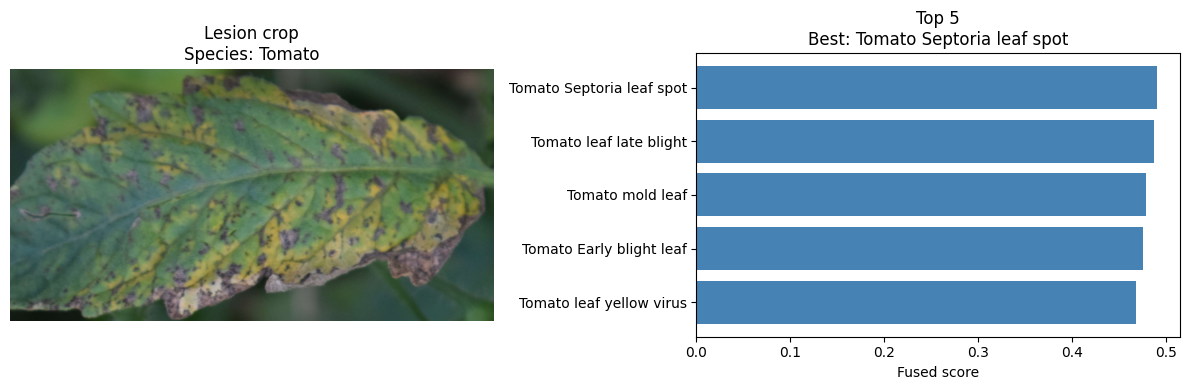

Species  : Tomato
Disease  : Tomato Septoria leaf spot
Score    : 0.4901


In [28]:
import os

# 1. Get ALL images regardless of where they are in the folder
all_images = glob.glob('/content/PlantDoc-Dataset/**/*.jpg', recursive=True) + \
             glob.glob('/content/PlantDoc-Dataset/**/*.png', recursive=True)

# 2. Filter for Tomato (case-insensitive)
tomato_imgs = [p for p in all_images if 'tomato' in p.lower()]

print(f"Total images found: {len(all_images)}")
print(f"Tomato images found: {len(tomato_imgs)}")

# 3. Run predict on the first one if found
if tomato_imgs:
    print(f"Testing on: {tomato_imgs[0]}")
    result = predict(tomato_imgs[0])
else:
    print("Bhai, still 0? Check the folder names on the left sidebar in Colab!")